In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import umap

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_clusters = pd.read_pickle("documentos_2004_2024_preprocesados.pkl")

print("Shape:", df_clusters.shape)
print("Tipo de resuelve_tokens:", type(df_clusters["resuelve_tokens"].iloc[0]))
print(df_clusters["resuelve_tokens"].head(3).to_list())

Shape: (23518, 8)
Tipo de resuelve_tokens: <class 'list'>
[['modificar', 'prestacion', 'servicios', 'salud', 'sistema', 'seguridad', 'social'], ['aprobar', 'presupuesto', 'fondos', 'generales', 'vigencia', 'fiscal'], ['aprobar', 'presupuesto', 'fondos', 'seguridad', 'social', 'vigencia', 'fiscal']]


In [3]:
df_clusters["resuelve_doc"] = df_clusters["resuelve_tokens"].apply(lambda toks: " ".join(toks))

print(df_clusters["resuelve_doc"].head(3).to_list())

['modificar prestacion servicios salud sistema seguridad social', 'aprobar presupuesto fondos generales vigencia fiscal', 'aprobar presupuesto fondos seguridad social vigencia fiscal']


In [4]:
docs = df_clusters["resuelve_doc"].fillna("").tolist()

model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

embeddings = embedder.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Shape embeddings:", embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2622.30it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 368/368 [05:51<00:00,  1.05it/s]


Shape embeddings: (23518, 384)


In [6]:
# Guardado opcional para no recalcular
np.save("embeddings_resuelve_umap.npy", embeddings)

In [7]:
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    metric="cosine",
    random_state=42
)

embeddings_reducidos = reducer.fit_transform(embeddings)

print("Shape embeddings reducidos:", embeddings_reducidos.shape)

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape embeddings reducidos: (23518, 10)


In [8]:
# Guardar embeddings reducidos
np.save("embeddings_resuelve_umap.npy", embeddings_reducidos)

In [9]:
resultados_kmeans = []

for k in range(5, 31):
    modelo = KMeans(
        n_clusters=k,        # cantidad de clusters a probar
        random_state=42,     # hace reproducible el resultado
        n_init=20            # múltiples inicializaciones, escoge la mejor por inercia
    )
    labels = modelo.fit_predict(embeddings_reducidos)
    resultados_kmeans.append({
        "k": k,
        "inercial": modelo.inertia_
    })

# Convertir a DataFrame
resultados_kmeans = pd.DataFrame(resultados_kmeans)

print(resultados_kmeans)

     k       inercial
0    5  200529.812500
1    6  181622.812500
2    7  165717.359375
3    8  149846.875000
4    9  136727.953125
5   10  125172.906250
6   11  118393.234375
7   12  109432.007812
8   13  100741.531250
9   14   95821.804688
10  15   88390.000000
11  16   83471.445312
12  17   78692.546875
13  18   74756.195312
14  19   71685.351562
15  20   67757.781250
16  21   63925.808594
17  22   60564.773438
18  23   57468.648438
19  24   55701.929688
20  25   53544.851562
21  26   50608.375000
22  27   48114.734375
23  28   46495.757812
24  29   44711.785156
25  30   42341.820312


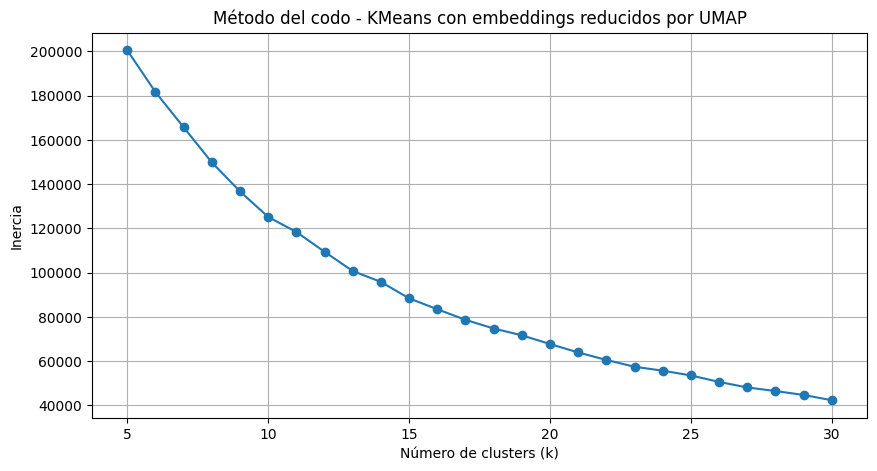

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_kmeans["k"], resultados_kmeans["inercial"], marker="o")
plt.title("Método del codo - KMeans con embeddings reducidos por UMAP")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [12]:
resultados_kmeans.to_excel("resultados_kmeans_umap.xlsx", index=False)
resultados_kmeans.to_csv("resultados_kmeans_umap.csv", index=False)

In [13]:
best_k = 10

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df_clusters["cluster_kmeans"] = kmeans_final.fit_predict(embeddings_reducidos)

print(df_clusters["cluster_kmeans"].value_counts().sort_index())


cluster_kmeans
0    6461
1    3866
2    3391
3     158
4    3148
5     458
6    4611
7      76
8    1291
9      58
Name: count, dtype: int64


In [14]:
for c in sorted(df_clusters["cluster_kmeans"].unique()):
    print(f"\n===== CLUSTER KMEANS {c} =====")
    
    muestra = df_clusters.loc[
        df_clusters["cluster_kmeans"] == c,
        ["resuelve", "resuelve_tokens"]
    ].head(8) 

    for _, fila in muestra.iterrows():
        print("Texto:", fila["resuelve"])
        print("Tokens:", fila["resuelve_tokens"])
        print("-" * 100)


===== CLUSTER KMEANS 0 =====
Texto: modificar articulos 45 66 y 74 del acuerdo superior 230 del 5 de agosto de 2002 estatuto de carrera administrativa
Tokens: ['modificar', 'articulos', 'estatuto', 'carrera']
----------------------------------------------------------------------------------------------------
Texto: modificar acuerdo superior 113 del 19 de mayo de 1997 reglamenta sistema general de viaticos
Tokens: ['modificar', 'reglamenta', 'sistema', 'general', 'viaticos']
----------------------------------------------------------------------------------------------------
Texto: aclarar articulo 33 del acuerdo superior 253 del 18 de febrero de 2003 estatuto profesor de catedra y ocasional
Tokens: ['aclarar', 'estatuto', 'catedra', 'ocasional']
----------------------------------------------------------------------------------------------------
Texto: adoptar reglamento interno consejo superior universitario
Tokens: ['adoptar', 'reglamento', 'interno']
--------------------------------

In [15]:
df_clusters.to_pickle("documentos_clusterizados_kmeans_umap.pkl")
df_clusters.to_excel("documentos_clusterizados_kmeans_umap.xlsx", index=False)

In [4]:
df_clusters = pd.read_pickle("documentos_clusterizados_kmeans_umap.pkl")
embeddings = np.load("embeddings_resuelve_umap.npy")

In [5]:
print(type(embeddings))
print(embeddings.shape)

<class 'numpy.ndarray'>
(23518, 10)


In [4]:
from sklearn.decomposition import PCA

C:\Users\sebas\AppData\Local\Temp\ipykernel_11392\3033743669.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clusters_ordenados))


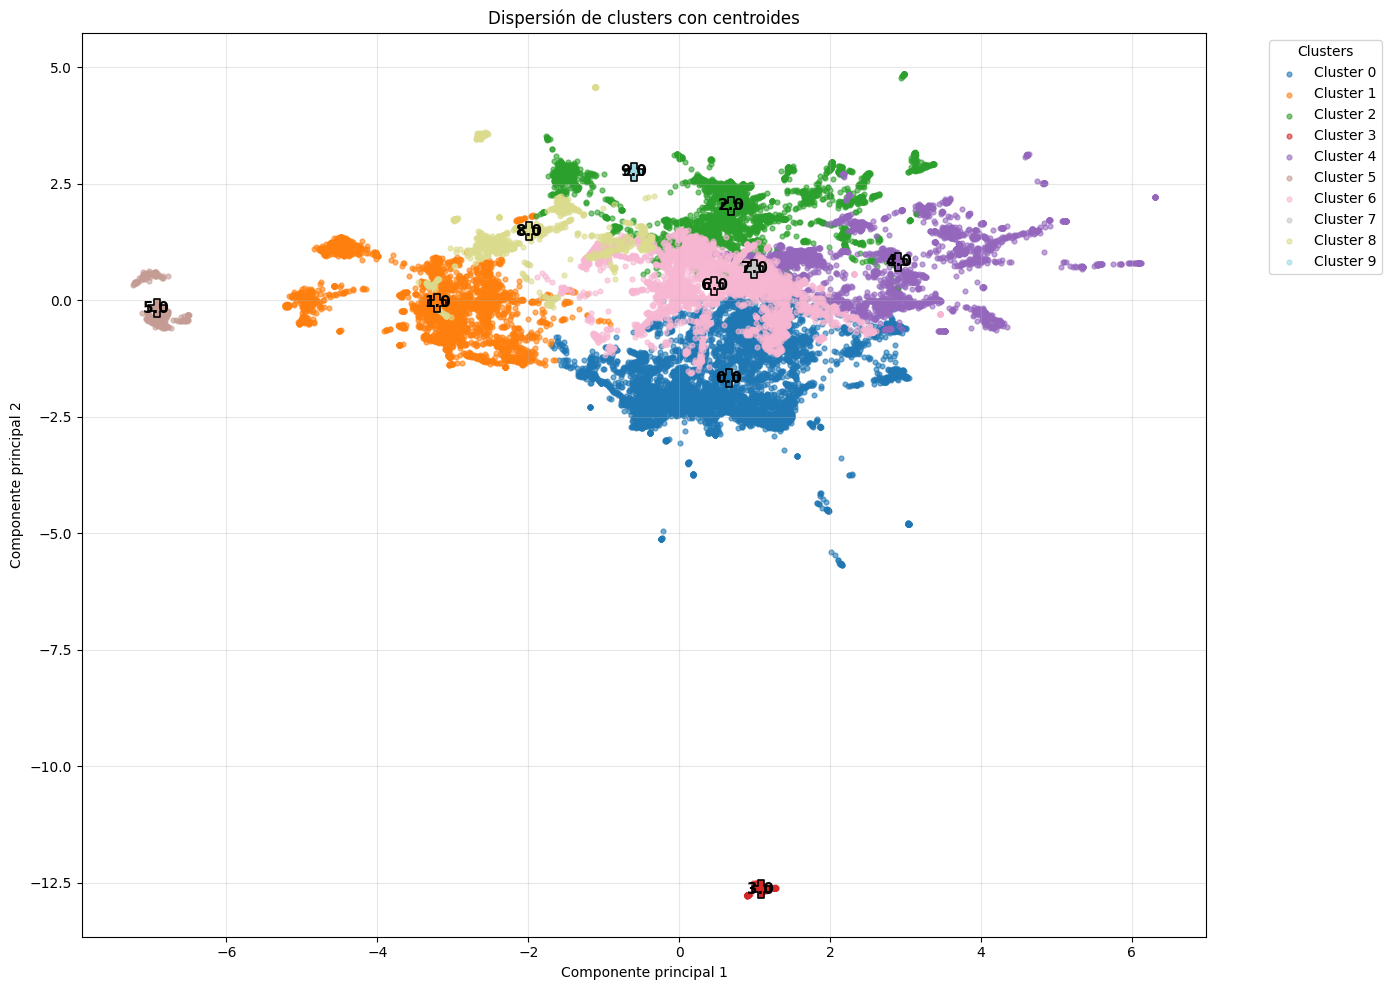

In [6]:
# Reducir embeddings a 2D para visualización
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
#Crear DataFrame para graficar
df_plot = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "cluster": df_clusters["cluster_kmeans"].values
})
# Calcular centroides visuales
centroides = df_plot.groupby("cluster")[["x", "y"]].mean().reset_index()
# Graficar clusters
plt.figure(figsize=(14, 10))
# Obtener lista ordenada de clusters
clusters_ordenados = sorted(df_plot["cluster"].unique())
# Mapa de colores
cmap = plt.cm.get_cmap("tab20", len(clusters_ordenados))
# Dibujar cada cluster por separado para que la leyenda quede bien
for i, cluster_id in enumerate(clusters_ordenados):
    datos_cluster = df_plot[df_plot["cluster"] == cluster_id]
    
    plt.scatter(
        datos_cluster["x"],
        datos_cluster["y"],
        s=12,
        alpha=0.6,
        color=cmap(i),
        label=f"Cluster {cluster_id}"
    )
# Dibujar centroides
for i, row in centroides.iterrows():
    cluster_id = row["cluster"]
    color_idx = clusters_ordenados.index(cluster_id)
    
    plt.scatter(
        row["x"],
        row["y"],
        s=180,
        color=cmap(color_idx),
        marker="P",
        edgecolors="black",
        linewidths=1.2,
        zorder=5
    )
    
    plt.text(
        row["x"],
        row["y"],
        str(cluster_id),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        zorder=6
    )
# Detalles finales
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Dispersión de clusters con centroides")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

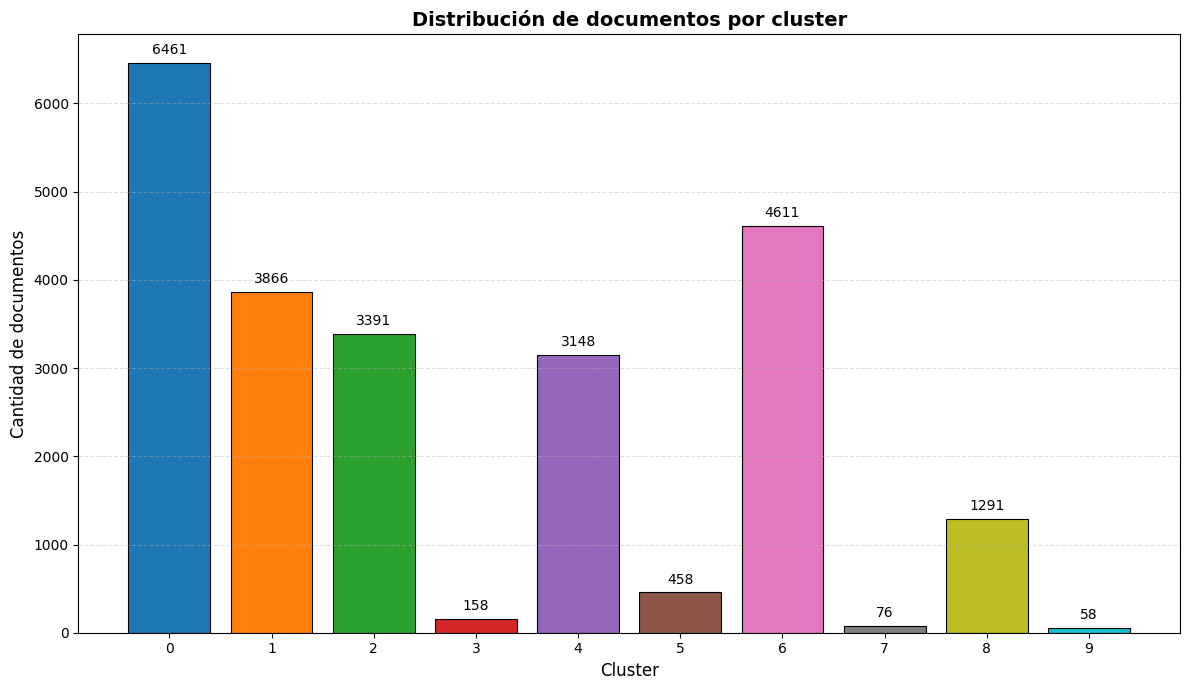

In [7]:
# Conteo de documentos por cluster

conteo_clusters = df_clusters["cluster_kmeans"].value_counts().sort_index()

# Índices y valores
clusters = conteo_clusters.index.tolist()
cantidades = conteo_clusters.values

# Colores diferenciados
colores = plt.cm.tab10(np.linspace(0, 1, len(clusters)))


# Gráfico de barras

plt.figure(figsize=(12, 7))
barras = plt.bar(clusters, cantidades, color=colores, edgecolor="black", linewidth=0.8)

# Etiquetas encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + max(cantidades) * 0.01,   # pequeño desplazamiento vertical
        f"{int(altura)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Títulos y ejes
plt.title("Distribución de documentos por cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Cantidad de documentos", fontsize=12)

# Marcas del eje X
plt.xticks(clusters, fontsize=10)
plt.yticks(fontsize=10)

# Cuadrícula horizontal sutil
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Ajuste de márgenes
plt.tight_layout()

plt.show()

In [1]:
from wordcloud import WordCloud

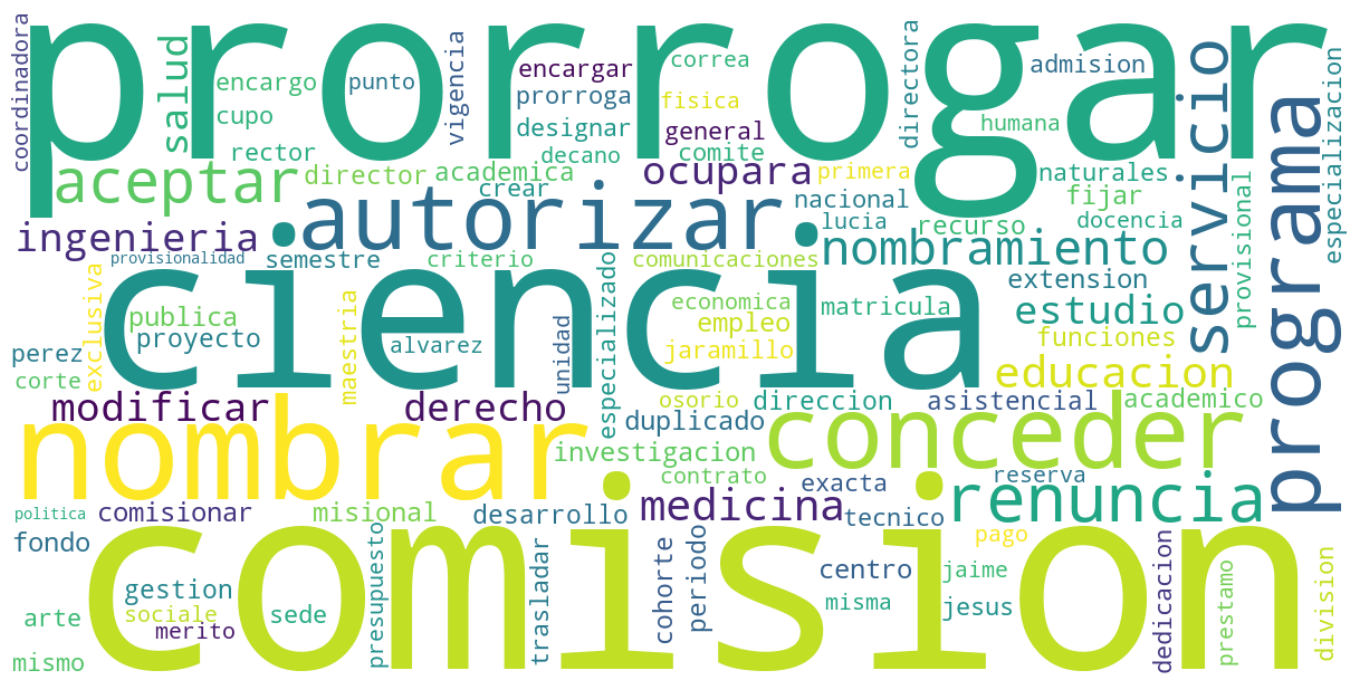

In [9]:
# Unir todos los tokens del DataFrame en un solo texto
texto_general = " ".join(
    " ".join(tokens) for tokens in df_clusters["resuelve_tokens"] if isinstance(tokens, list)
)

# Generar nube de palabras
nube = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    max_words=100
).generate(texto_general)

# Graficar
plt.figure(figsize=(14, 7))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
import os

In [8]:
# Carpeta de salida
carpeta_salida = "nubes_por_cluster"
os.makedirs(carpeta_salida, exist_ok=True)

# Obtener clusters únicos ordenados
clusters = sorted(df_clusters["cluster_kmeans"].unique())

for cluster_id in clusters:
    # Filtrar textos del cluster
    textos_cluster = df_clusters.loc[
        df_clusters["cluster_kmeans"] == cluster_id,
        "resuelve_tokens"
    ]

    # Unir tokens en un solo texto
    texto_unido = " ".join(
        " ".join(tokens) for tokens in textos_cluster if isinstance(tokens, list)
    )

    # Validar que haya texto
    if not texto_unido.strip():
        print(f"Cluster {cluster_id}: sin texto, no se generó nube.")
        continue

    # Crear nube
    nube = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        collocations=False,
        max_words=60,
        min_font_size=10
    ).generate(texto_unido)

    # Crear figura individual
    plt.figure(figsize=(12, 6))
    plt.imshow(nube, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Nube de palabras - Cluster {cluster_id}", fontsize=16, fontweight="bold")

    # Guardar imagen
    ruta_archivo = os.path.join(carpeta_salida, f"nube_cluster_{cluster_id}.png")
    plt.savefig(ruta_archivo, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Guardada: {ruta_archivo}")

Guardada: nubes_por_cluster\nube_cluster_0.png
Guardada: nubes_por_cluster\nube_cluster_1.png
Guardada: nubes_por_cluster\nube_cluster_2.png
Guardada: nubes_por_cluster\nube_cluster_3.png
Guardada: nubes_por_cluster\nube_cluster_4.png
Guardada: nubes_por_cluster\nube_cluster_5.png
Guardada: nubes_por_cluster\nube_cluster_6.png
Guardada: nubes_por_cluster\nube_cluster_7.png
Guardada: nubes_por_cluster\nube_cluster_8.png
Guardada: nubes_por_cluster\nube_cluster_9.png
